In [ ]:
from pathlib import Path

import geopandas as gpd
import pandas as pd

from satchip import models, download_data, merge_modality, generate_labels, chip_data, view

/home/wbhorn/miniforge3/envs/satchip/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
modality = models.HLS_S30

DATA_PATH = Path.cwd() / 'data'
MODALITY_PATH = DATA_PATH / modality['id']

RAW_DATA_PATH = MODALITY_PATH / 'raw'
MERGED_PATH = MODALITY_PATH / 'merged'
REPROJECTED_PATH = MODALITY_PATH / 'wgs84'
STACKED_PATH = MODALITY_PATH / 'stacked'
WARPED_PATH = MODALITY_PATH / 'warped'
CHIPS_PATH = MODALITY_PATH / 'chips'

In [ ]:
shp_path = 'hwds_pristine'
df = gpd.read_file(shp_path)

df['SwathDate'] = pd.to_datetime(df['SwathDate'], format='%Y-%m-%d')
df['HLSDate'] = pd.to_datetime(df['HLSDate'], format='%Y-%m-%d')

In [ ]:
swath = df.iloc[1]
swath

SwathDate                                   2019-07-09 00:00:00
HLSID                                                      102a
MODISID                                                     102
Visibility                                                    2
HLSDate                                     2019-07-17 00:00:00
geometry      POLYGON Z ((-99.49996223199997 40.270482574000...
Name: 1, dtype: object

In [ ]:
event = models.Event(name=swath['HLSID'], date=swath['SwathDate'], wgs84_geometry=swath['geometry'], buffer_m=10000)
print(event)

Event(name='102a', date=Timestamp('2019-07-09 00:00:00'), wgs84_geometry=<POLYGON Z ((-99.5 40.27 0, -99.476 40.268 0, -99.458 40.275 0, -99.428 40.2...>, buffer_m=10000)


In [ ]:
local_files = download_data.download_data(event, modality, RAW_DATA_PATH)

Logging in to earthaccess


QUEUEING TASKS | : 100%|██████████| 18/18 [00:00<00:00, 9419.52it/s]
PROCESSING TASKS | : 100%|██████████| 18/18 [00:00<00:00, 277564.24it/s]
COLLECTING RESULTS | : 100%|██████████| 18/18 [00:00<00:00, 354448.23it/s]


In [ ]:
merged_event = merge_modality.merge_modality(local_files, modality, event=event, output_path=MERGED_PATH)

In [ ]:
merged_event

[PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.B.tif'),
 PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.G.tif'),
 PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.R.tif'),
 PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.N.tif'),
 PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.SW1.tif'),
 PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.SW2.tif'),
 PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/merged/102a.HLS_S30.2019-07-09.Fmask.tif')]

In [ ]:
stacked_filename = MERGED_PATH / f'{swath["HLSID"]}.stacked.tif'
data_bands, fmask = merged_event[:-1], merged_event[-1]

stacked = merge_modality.stack_bands(data_bands, stacked_filename)

In [ ]:
stacked, fmask = merge_modality.reproject_files([stacked, fmask], REPROJECTED_PATH)

In [ ]:
label = generate_labels.binary_mask_from_template(stacked, event, REPROJECTED_PATH)

generated: /home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/wgs84/102a.MASK.tif


In [ ]:
mask, bands, fmask = merge_modality.warp_to_reference(
    reference_path=label,
    data_files=[stacked, fmask],
    output_dir=WARPED_PATH,
    bounding_box_wgs84=event.buffered_geometry().bounds,
)

In [ ]:
import rasterio

with rasterio.open(bands) as ds:
    bounds = ds.bounds
    full_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    band_data = ds.read()

ValueError: Expected a projection subclass. Cannot handle a <class 'affine.Affine'> in imshow.

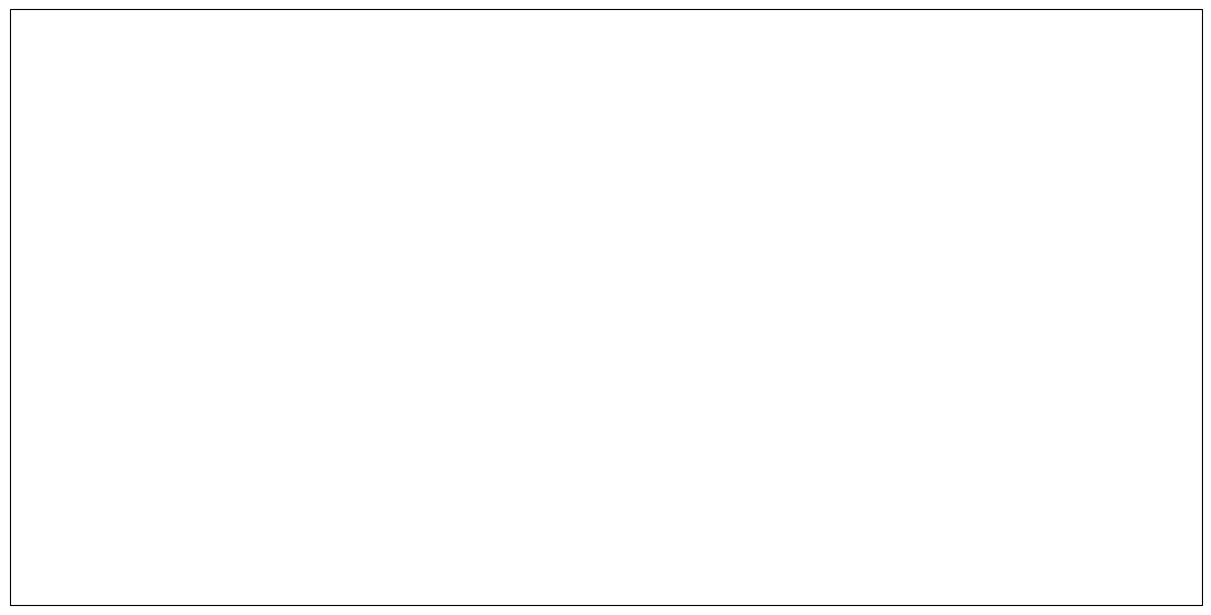

In [ ]:
view.view_merged(bands, event, modality, [2, 1, 0], quite=False)

In [ ]:
grid = chip_data.make_grid_from_reference(mask)

In [ ]:
label_chips = chip_data.chip_data(grid, mask, CHIPS_PATH / 'LABELS')
data_chips = chip_data.chip_data(grid, bands, CHIPS_PATH / modality['id'])
fmask_chips = chip_data.chip_data(grid, fmask, CHIPS_PATH / 'FMASK')

In [ ]:
stacks = chip_data.make_chip_stacks(data_chips, fmask_chips, label_chips, models.HLS_S30)
filtered = chip_data.filter_chips(stacks)

In [ ]:
filtered

[ChipStack(id='001.001', data=PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/chips/HLS_S30/001.001.102a.stacked.tif'), validation_mask=PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/chips/FMASK/001.001.102a.HLS_S30.2019-07-09.Fmask.tif'), label=PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/chips/LABELS/001.001.102a.MASK.tif'), modality={'id': 'HLS_S30', 'collection': 'HLSS30', 'bands': (Band(id='B02', name='Blue', shortname='B'), Band(id='B03', name='Green', shortname='G'), Band(id='B04', name='Red', shortname='R'), Band(id='B8A', name='NIR Narrow', shortname='N'), Band(id='B11', name='SWIR 1', shortname='SW1'), Band(id='B12', name='SWIR 2', shortname='SW2'), Band(id='Fmask', name='Cloud Mask', shortname='Fmask'))}),
 ChipStack(id='001.002', data=PosixPath('/home/wbhorn/Repositories/fm/satchip/notebooks/data/HLS_S30/chips/HLS_S30/001.002.102a.stacked.tif'), validation_mask=PosixPath('/home/wbhorn/Repositories/fm/s